# Irrigation Need Prediction — KGMON-Inspired Modelling Pipeline

**Competition:** Kaggle Playground Series — Predict Irrigation Need  
**Task:** Multi-class classification (Low / Medium / High)  
**Metric:** Balanced Accuracy  
**Approach:** Adapted from the [KGMON Playbook for Tabular Data](https://www.kaggle.com/competitions/playground-series-s5e4/discussion/577291) — feature engineering first, diverse GBDT ensemble, stacking.

This notebook focuses on the modelling pipeline. EDA has been completed separately and informs the feature engineering decisions below.

---

## Strategy at a Glance

The original dataset behind this competition's synthetic data is the [Irrigation Water Requirement Prediction Dataset](https://www.kaggle.com/datasets/miadul/irrigation-water-requirement-prediction-dataset/data) (10,000 rows). Kaggle's synthetic generator created 630k training rows by remixing and lightly perturbing the original values. We exploit this relationship through:

1. **Snap features** — map noisy synthetic floats back to the nearest original value, recovering the "true" signal
2. **Original dataset lookup** — KDTree nearest-neighbor features using the 10k original rows as anchors
3. **Domain interactions** — physically meaningful feature crosses (evapotranspiration proxies, water balance, moisture deficit)
4. **Radix & digit features** — encode synthetic generation artifacts and (numeric, categorical) pair interactions
5. **Nested target encoding** — leak-free target statistics on categorical bigrams, trigrams, and binned numerics
6. **Diverse ensemble** — XGBoost, LightGBM, CatBoost (multiple configs), Embedding MLP, stacked via logistic regression
7. **Hill-climbing model selection** — greedy forward selection to find the optimal model subset
8. **Second-level stacking** — GBDT models trained on OOF predictions as meta-features

### Key References

| Technique | Source | Section |
|-----------|--------|---------|
| Snap features | [KGMON 1st Place Churn](https://www.kaggle.com/competitions/playground-series-s5e4/discussion/577291) | §2.1 |
| Digit extraction | KGMON Churn | §2.2 |
| Nested target encoding | KGMON Churn | §2.3 |
| Arithmetic interactions | KGMON Churn | §2.4 |
| Multi-scale binning | KGMON Churn | §2.5 |
| Categorical bigrams/trigrams | KGMON Churn | §2.6 |
| Frequency / count encoding | KGMON Churn | §2.7 |
| KDTree original lookup | KGMON Churn | §2.9 |
| Radix interaction features | KGMON Churn | §2.10 |
| PCA / manifold projection | KGMON Churn | §2.12 |
| Hill-climbing ensemble selection | KGMON Churn | §5 |
| L2 logistic regression stacking | KGMON Churn | §5 |
| Evapotranspiration modelling | [FAO Penman-Monteith](https://www.fao.org/3/x0490e/x0490e06.htm) | — |

## 1. Setup & Data Loading

In [2]:
import os, glob, pickle
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from scipy.spatial import cKDTree

import xgboost as xgb
import lightgbm as lgb
import catboost as cb
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
N_FOLDS = 5
np.random.seed(SEED)

# ── Checkpoint utilities ──
CKPT_DIR = 'checkpoints'
os.makedirs(CKPT_DIR, exist_ok=True)

def save_checkpoint(obj, name):
    path = os.path.join(CKPT_DIR, name)
    if isinstance(obj, np.ndarray):
        np.save(path, obj)
    elif isinstance(obj, pd.DataFrame):
        obj.to_pickle(path)
    else:
        with open(path, 'wb') as f:
            pickle.dump(obj, f)
    print(f"  💾 Saved {name}")

def load_checkpoint(name, dtype='npy'):
    path = os.path.join(CKPT_DIR, name)
    if not os.path.exists(path):
        return None
    if dtype == 'npy':
        return np.load(path)
    elif dtype == 'pkl':
        return pd.read_pickle(path)
    else:
        with open(path, 'rb') as f:
            return pickle.load(f)

def make_single_model_submission(test_preds_proba, test_ids, le_target, model_name):
    labels = le_target.inverse_transform(test_preds_proba.argmax(axis=1))
    sub = pd.DataFrame({'id': test_ids, 'Irrigation_Need': labels})
    path = f'submission_{model_name}.csv'
    sub.to_csv(path, index=False)
    print(f"  📄 Submission saved: {path} | {dict(sub['Irrigation_Need'].value_counts())}")
    return sub

print("Libraries loaded ✓")

Libraries loaded ✓


In [3]:
train = pd.read_csv('../data/train.csv')
test  = pd.read_csv('../data/test.csv')
orig  = pd.read_csv('../data/irrigation_prediction.csv')

print(f"Train: {train.shape}  |  Test: {test.shape}  |  Original: {orig.shape}")
print(f"\nTarget distribution:")
print(train['Irrigation_Need'].value_counts(normalize=True).round(4))

Train: (630000, 21)  |  Test: (270000, 20)  |  Original: (10000, 20)

Target distribution:
Irrigation_Need
Low       0.5872
Medium    0.3795
High      0.0333
Name: proportion, dtype: float64


## 2. Understanding the Synthetic Generation

Before engineering features, we need to understand *how* the synthetic data was generated from the original. This directly determines which KGMON techniques transfer to our dataset.

The Kaggle Playground Series uses [CTGAN](https://arxiv.org/abs/1907.00503) (Conditional Tabular GAN) or similar deep generative models to synthesise data from a real-world seed dataset. The generator learns the joint distribution of features and target, then samples new rows — but leaves fingerprints: rounding artifacts in numeric columns, value-pool reuse, and distributional drift between synthetic and original frequencies.

Detecting these fingerprints is the first step of the KGMON Playbook (see [Chris Deotte's blog](https://www.kaggle.com/competitions/playground-series-s5e4/discussion/577291), Section 2.1–2.2).

In [4]:
cat_cols = ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season',
            'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']

num_cols = ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity',
            'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours',
            'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']

# Classify columns: exact copy vs noisy perturbation
exact_cols, noisy_cols = [], []
for col in num_cols:
    orig_set = set(orig[col].unique())
    train_set = set(train[col].unique())
    overlap_pct = len(train_set & orig_set) / len(train_set)
    if len(train_set - orig_set) == 0 or overlap_pct > 0.99:
        exact_cols.append(col)
    else:
        noisy_cols.append(col)

print("EXACT columns (train values ⊆ original):")
for col in exact_cols:
    print(f"  {col}: {train[col].nunique()} unique values")

print(f"\nNOISY columns (generator added perturbation):")
for col in noisy_cols:
    extra = len(set(train[col].unique()) - set(orig[col].unique()))
    print(f"  {col}: {extra} new values in train")

EXACT columns (train values ⊆ original):
  Soil_pH: 341 unique values
  Organic_Carbon: 131 unique values
  Electrical_Conductivity: 341 unique values
  Sunlight_Hours: 701 unique values
  Wind_Speed_kmh: 1935 unique values
  Field_Area_hectare: 1466 unique values

NOISY columns (generator added perturbation):
  Soil_Moisture: 571 new values in train
  Temperature_C: 78 new values in train
  Humidity: 1232 new values in train
  Rainfall_mm: 10154 new values in train
  Previous_Irrigation_mm: 3358 new values in train


### Key Finding

The synthetic generator uses two strategies:
- **Exact columns** (Soil_pH, Organic_Carbon, etc.) are sampled directly from the original dataset's value pool — no noise added. These have identical unique-value sets between train and original.
- **Noisy columns** (Rainfall_mm, Humidity, etc.) have small perturbations, but ~95-99% of values still match originals. The perturbation magnitudes are themselves informative features.
- **Rows are remixed** — feature values from different original rows are combined, so no direct row-to-row mapping exists. This means KDTree lookup gives ~63% target agreement (useful but imperfect).

This pattern is typical of CTGAN-style generators and closely mirrors the IBM Churn dataset used in the KGMON writeup, where `MonthlyCharges` and `TotalCharges` had similar noise characteristics.

## 3. Feature Engineering

> *"Feature engineering was the dominant driver of performance."*  
> — KGMON 1st Place Solution, Section 2

We implement 10 feature engineering families, each adapted from specific sections of the KGMON writeup. The features are built in a modular pipeline so each technique can be tested independently.

In [5]:
le_target = LabelEncoder()
train['target'] = le_target.fit_transform(train['Irrigation_Need'])
orig['target'] = le_target.transform(orig['Irrigation_Need'])
y = train['target'].values

print("Target encoding:", dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))
print(f"Class counts: {np.bincount(y)}")

Target encoding: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
Class counts: [ 21009 369917 239074]


### 3.1 Snap Features (KGMON §2.1)

For columns where the synthetic generator added noise, we map each value back to its nearest value in the original dataset using binary search. This recovers the "true" pre-perturbation feature.

The KGMON solution applied this to `MonthlyCharges` and `TotalCharges`:
```
MC_snap      = nearest MonthlyCharges in original IBM data
MC_snap_diff = MonthlyCharges - MC_snap   # synthetic noise magnitude
```

We apply the same logic to our 5 noisy columns. The snap value recovers the original feature; the residual encodes the generator's perturbation magnitude, which can correlate with how "synthetic" a row is — and therefore how reliable its label might be.

### 3.2 Digit & Decimal Extraction (KGMON §2.2)

> *"The most pervasive technique. Extract the digit at every decimal position."*

Synthetic data generators often leave fingerprints in the decimal digits of numeric columns. For example, a generator that rounds to 2 decimal places will produce different digit distributions than real-world measurements. By extracting individual decimal digits, we give the model access to these artifacts as classification features.

```
frac    = x - floor(x)
d1      = floor(frac * 10)         # 1st decimal digit
d2      = floor(frac * 100) % 10   # 2nd decimal digit
mod10   = floor(x) % 10            # last integer digit
is_round = frac < 0.005            # was this value rounded?
```

The KGMON solution used digit features in ~60 of 150 models, making it one of the most widely applied techniques.

### 3.3 Domain Interactions (KGMON §2.4)

The KGMON solution's `TC_deviation = TotalCharges - tenure * MonthlyCharges` captured how much a customer's actual charges deviated from what their tenure predicted. This was "particularly powerful" because it encoded a domain-specific invariant.

We apply the same philosophy to agricultural irrigation. The [FAO Penman-Monteith equation](https://www.fao.org/3/x0490e/x0490e06.htm) tells us that evapotranspiration (water loss) depends on temperature, sunlight, wind, and humidity. Our interaction features approximate these physical relationships:

- **Evapotranspiration proxy:** `Temperature × Sunlight / Humidity` — higher values = more water loss = more irrigation needed
- **Water balance:** `Rainfall - Previous_Irrigation` — net water input to the field
- **Irrigation deviation:** `Previous_Irrigation - (Rainfall × Field_Area / 1000)` — analogous to `TC_deviation`, captures whether a field received more or less irrigation than rainfall alone would suggest
- **Moisture deficit:** `Soil_Moisture - Rainfall/100` — whether natural rainfall is sufficient

These interactions give tree models access to physically meaningful decision boundaries that would otherwise require multiple splits to approximate.

### 3.4 KDTree Original Dataset Lookup (KGMON §2.9)

> *"Build a cKDTree on the standardized columns of the original IBM rows. For each synthetic row, find the nearest original customer and attach their churn label as a feature. This provides a zero-leakage, noise-free ground truth anchor."*

We build two KDTrees:
1. **Full-feature KDTree:** All 11 numeric columns standardised — gives a holistic nearest-neighbor match
2. **Snap-column KDTree:** Only the exact + snapped columns — tighter matching on the "clean" signal

For each synthetic row, we extract:
- Distance to nearest original neighbor (measures how "typical" a synthetic row is)
- Target class probabilities among k=1,3,5 nearest neighbors (zero-leakage label signal)

Since rows are remixed (not copied), the nearest neighbor's target label agrees with the synthetic label ~63% of the time. This isn't perfect, but it's substantially above the ~59% base rate of the majority class, making it a genuinely useful feature.

### 3.5 Frequency & Drift Ratio Encoding (KGMON §2.7)

> *"The frequency encodes how many synthetic rows cluster around each original value, which correlates with the original customer's representativeness."*

For each numeric column, we compute:
- **Original frequency:** How common is this value in the 10k original dataset? Values that appear frequently in the original are more "typical" archetypes.
- **Train frequency:** How common is this value in the 630k synthetic data?
- **Drift ratio:** `log1p(train_freq / orig_freq)` — measures how much the generator over/under-sampled each value. Oversampled values may carry different noise characteristics.

The KGMON solution found frequency encoding "especially powerful for MC_snap (1,584 unique values)" and we expect similar results for our low-cardinality exact columns.

### 3.6 Radix Interaction Features (KGMON §2.10)

> *"Encodes a (continuous, categorical) pair as a single integer category. Very natural for tree models: a single split on this integer is equivalent to splitting on both the numeric value and the categorical value simultaneously."*

```python
radix = int(MC_snap * 100) + cat_code * 100_000
```

This is elegant because tree models can only split on one feature at a time. To approximate a joint split on (numeric, categorical), a tree needs at least 2 levels. A radix feature collapses this into a single split — effectively giving the tree a "pre-computed interaction" that it can use in one decision node.

We apply this to high-signal (numeric, categorical) pairs identified from our EDA: Rainfall × Crop_Type, Temperature × Season, Soil_Moisture × Soil_Type.

### 3.7 Categorical Bigrams & Trigrams (KGMON §2.6)

> *"Trigrams extend [bigrams] to 3-way combinations. Nested TE on these combos captures joint churn profiles unavailable to per-column TE."*

Bigrams concatenate two categorical columns (e.g., `Crop_Type__Season`). Trigrams extend this to three columns (e.g., `Crop_Type__Season__Soil_Type`). These cross-features capture interaction effects that are invisible when encoding each column independently.

The KGMON solution found the top-signal pairs were `Contract × InternetService`, `Contract × PaymentMethod`, and `InternetService × PaymentMethod`. In our agricultural domain, we expect the strongest interactions between crop characteristics, environmental conditions, and irrigation method.

### 3.8 PCA / Manifold Projection Features (KGMON §2.12)

> *"Fit PCA on the original IBM data, then project each synthetic row into that space. This gives the model explicit geometric information about how each synthetic customer relates to the true data manifold."*

We fit PCA on the 10k original dataset's numeric columns. When projecting synthetic rows into this space:
- **PCA components** capture the dominant variance directions of the *real* data
- **Reconstruction error** measures how well the original PCA model explains each synthetic row — rows that reconstruct poorly are "out of distribution" relative to the original data

This is conceptually similar to the Denoising Autoencoder (DAE) approach from KGMON §4.14, but much cheaper to compute.

### 3.9 Original Dataset Target Priors (KGMON §2.3)

> *"Original IBM priors: churn probability per feature value computed once from the 7,032-row original dataset — zero leakage, as the original data carries no synthetic training labels."*

We compute target statistics (mean, std) per categorical value from the original 10k dataset. These are completely independent of the synthetic training labels and provide a stable, zero-leakage prior.

### 3.10 Feature Engineering Pipeline

All feature engineering is wrapped in modular functions. Target encoding is handled separately inside the CV loop to prevent leakage.

In [6]:
# ── 3.1 Snap Features ──
def build_snap_features(df, orig_df, noisy_cols):
    features = {}
    for col in noisy_cols:
        orig_vals = np.sort(orig_df[col].unique())
        vals = df[col].values
        idx = np.searchsorted(orig_vals, vals, side='left')
        idx = np.clip(idx, 1, len(orig_vals) - 1)
        left, right = orig_vals[idx - 1], orig_vals[idx]
        snap = np.where((vals - left) < (right - vals), left, right)
        features[f'{col}_snap'] = snap
        features[f'{col}_snap_diff'] = vals - snap
        features[f'{col}_snap_abs_diff'] = np.abs(vals - snap)
    return pd.DataFrame(features, index=df.index)


# ── 3.2 Digit & Decimal Extraction ──
def build_digit_features(df, num_cols):
    features = {}
    for col in num_cols:
        x = df[col].values
        frac = x - np.floor(x)
        features[f'{col}_d1'] = np.floor(frac * 10).astype(int)
        features[f'{col}_d2'] = (np.floor(frac * 100) % 10).astype(int)
        features[f'{col}_frac100'] = np.round(frac * 100).astype(int)
        features[f'{col}_mod10'] = (np.floor(x) % 10).astype(int)
        features[f'{col}_is_round'] = (frac < 0.005).astype(int)
    return pd.DataFrame(features, index=df.index)


# ── 3.3 Domain Interactions ──
def build_domain_interactions(df):
    features = {}
    # Evapotranspiration proxies
    features['temp_x_humidity'] = df['Temperature_C'] * df['Humidity']
    features['temp_x_sunlight'] = df['Temperature_C'] * df['Sunlight_Hours']
    features['evapotranspiration_proxy'] = (df['Temperature_C'] * df['Sunlight_Hours']) / (df['Humidity'] + 1)
    features['wind_evap'] = df['Wind_Speed_kmh'] * df['Temperature_C']
    features['wind_x_dry'] = df['Wind_Speed_kmh'] * (100 - df['Humidity'])

    # Water balance
    features['water_balance'] = df['Rainfall_mm'] - df['Previous_Irrigation_mm']
    features['rainfall_x_moisture'] = df['Rainfall_mm'] * df['Soil_Moisture']
    features['rain_per_area'] = df['Rainfall_mm'] / (df['Field_Area_hectare'] + 1e-9)
    features['prev_irr_per_area'] = df['Previous_Irrigation_mm'] / (df['Field_Area_hectare'] + 1e-9)
    features['moisture_deficit'] = df['Soil_Moisture'] - df['Rainfall_mm'] / 100
    features['total_water_input'] = df['Rainfall_mm'] + df['Previous_Irrigation_mm']
    features['total_water_per_area'] = (df['Rainfall_mm'] + df['Previous_Irrigation_mm']) / (df['Field_Area_hectare'] + 1e-9)
    features['irr_deviation'] = df['Previous_Irrigation_mm'] - (df['Rainfall_mm'] * df['Field_Area_hectare'] / 1000)

    # Soil quality
    features['organic_x_moisture'] = df['Organic_Carbon'] * df['Soil_Moisture']
    features['conductivity_x_ph'] = df['Electrical_Conductivity'] * df['Soil_pH']
    features['ph_x_moisture'] = df['Soil_pH'] * df['Soil_Moisture']
    features['conductivity_x_moisture'] = df['Electrical_Conductivity'] * df['Soil_Moisture']

    # Ratios
    features['moisture_to_humidity'] = df['Soil_Moisture'] / (df['Humidity'] + 1)
    features['rain_to_temp'] = df['Rainfall_mm'] / (df['Temperature_C'] + 1)
    return pd.DataFrame(features, index=df.index)


# ── 3.4 KDTree Features (two trees: full + snap-only) ──
def build_knn_features(df, orig_df, num_cols, le_target, k=5):
    scaler = StandardScaler()
    orig_scaled = scaler.fit_transform(orig_df[num_cols])
    tree = cKDTree(orig_scaled)
    df_scaled = scaler.transform(df[num_cols])
    distances, indices = tree.query(df_scaled, k=k)

    features = {}
    features['nn_dist_1'] = distances[:, 0]
    features['nn_dist_mean5'] = distances.mean(axis=1)
    features['nn_dist_std5'] = distances.std(axis=1)

    orig_targets = orig_df['target'].values
    for kk in [1, 3, 5]:
        nn_targets = orig_targets[indices[:, :kk]]
        for cls_idx in range(len(le_target.classes_)):
            features[f'nn{kk}_prob_cls{cls_idx}'] = (nn_targets == cls_idx).mean(axis=1)
    return pd.DataFrame(features, index=df.index)


def build_snap_knn_features(df, orig_df, snap_cols, le_target, k=5):
    """Second KDTree using only exact/snap columns for tighter matching."""
    scaler = StandardScaler()
    orig_scaled = scaler.fit_transform(orig_df[snap_cols])
    tree = cKDTree(orig_scaled)
    df_scaled = scaler.transform(df[snap_cols])
    distances, indices = tree.query(df_scaled, k=k)

    features = {}
    features['snap_nn_dist_1'] = distances[:, 0]
    features['snap_nn_dist_mean5'] = distances.mean(axis=1)

    orig_targets = orig_df['target'].values
    for kk in [1, 3]:
        nn_targets = orig_targets[indices[:, :kk]]
        for cls_idx in range(len(le_target.classes_)):
            features[f'snap_nn{kk}_prob_cls{cls_idx}'] = (nn_targets == cls_idx).mean(axis=1)
    return pd.DataFrame(features, index=df.index)


# ── 3.5 Frequency & Drift Ratio Encoding ──
def build_frequency_features(df, orig_df, train_full, num_cols):
    features = {}
    for col in num_cols:
        # Original frequency
        orig_freq = orig_df[col].value_counts(normalize=True)
        features[f'{col}_orig_freq'] = df[col].map(orig_freq).fillna(0)
        orig_count = orig_df[col].value_counts()
        features[f'{col}_orig_count'] = df[col].map(orig_count).fillna(0)

        # Train frequency (computed on full train for consistency)
        train_freq = train_full[col].value_counts(normalize=True)
        features[f'{col}_train_freq'] = df[col].map(train_freq).fillna(0)

        # Drift ratio: how much did the generator over/under-sample this value?
        drift = {}
        for val in orig_freq.index:
            o = orig_freq.get(val, 0)
            t = train_freq.get(val, 0)
            drift[val] = np.log1p(t / (o + 1e-9))
        features[f'{col}_drift_ratio'] = df[col].map(drift).fillna(0)
    return pd.DataFrame(features, index=df.index)


# ── 3.6 Radix Interaction Features ──
def build_radix_features(df, cat_cols_for_radix):
    features = {}
    radix_pairs = [
        ('Rainfall_mm', 'Crop_Type'),
        ('Temperature_C', 'Season'),
        ('Soil_Moisture', 'Soil_Type'),
        ('Previous_Irrigation_mm', 'Irrigation_Type'),
        ('Humidity', 'Crop_Growth_Stage'),
        ('Sunlight_Hours', 'Region'),
    ]
    for num_col, cat_col in radix_pairs:
        cat_codes = df[cat_col].astype('category').cat.codes.to_numpy(dtype=np.int32)
        num_binned = pd.qcut(df[num_col], 100, labels=False, duplicates='drop').to_numpy(dtype=np.int32)
        features[f'radix_{num_col}_{cat_col}'] = num_binned + cat_codes * 1000
    return pd.DataFrame(features, index=df.index)


# ── 3.7 Categorical Bigrams & Trigrams ──
def build_categorical_features(df, cat_cols):
    features = {}
    bigram_pairs = [
        ('Crop_Type', 'Season'), ('Crop_Type', 'Soil_Type'),
        ('Crop_Type', 'Crop_Growth_Stage'), ('Crop_Type', 'Region'),
        ('Irrigation_Type', 'Water_Source'), ('Irrigation_Type', 'Soil_Type'),
        ('Soil_Type', 'Season'), ('Season', 'Region'),
        ('Crop_Growth_Stage', 'Season'), ('Mulching_Used', 'Irrigation_Type'),
    ]
    for c1, c2 in bigram_pairs:
        features[f'bi_{c1}_{c2}'] = df[c1].astype(str) + '__' + df[c2].astype(str)

    trigram_triples = [
        ('Crop_Type', 'Season', 'Soil_Type'),
        ('Crop_Type', 'Crop_Growth_Stage', 'Region'),
        ('Irrigation_Type', 'Water_Source', 'Season'),
        ('Crop_Type', 'Season', 'Irrigation_Type'),
        ('Soil_Type', 'Season', 'Region'),
    ]
    for c1, c2, c3 in trigram_triples:
        features[f'tri_{c1}_{c2}_{c3}'] = (
            df[c1].astype(str) + '__' + df[c2].astype(str) + '__' + df[c3].astype(str)
        )

    # Binary flags
    features['is_rainfed'] = (df['Irrigation_Type'] == 'Rainfed').astype(int)
    features['is_drip'] = (df['Irrigation_Type'] == 'Drip').astype(int)
    features['uses_mulching'] = (df['Mulching_Used'] == 'Yes').astype(int)
    return pd.DataFrame(features, index=df.index)


# ── 3.8 PCA / Manifold Projection ──
def build_manifold_features(df, orig_df, num_cols, n_components=8):
    scaler = StandardScaler()
    orig_scaled = scaler.fit_transform(orig_df[num_cols])
    pca = PCA(n_components=n_components, random_state=SEED)
    pca.fit(orig_scaled)
    df_scaled = scaler.transform(df[num_cols])
    projections = pca.transform(df_scaled)

    features = {}
    for i in range(n_components):
        features[f'pca_{i}'] = projections[:, i]
    reconstructed = pca.inverse_transform(projections)
    features['pca_recon_error'] = np.mean((df_scaled - reconstructed) ** 2, axis=1)
    return pd.DataFrame(features, index=df.index)


# ── 3.9 Original Target Priors ──
def build_original_target_priors(df, orig_df, cat_cols):
    features = {}
    for col in cat_cols:
        prior_mean = orig_df.groupby(col)['target'].mean()
        features[f'{col}_orig_target_mean'] = df[col].map(prior_mean).fillna(prior_mean.mean())
        prior_std = orig_df.groupby(col)['target'].std()
        features[f'{col}_orig_target_std'] = df[col].map(prior_std).fillna(prior_std.mean())
    return pd.DataFrame(features, index=df.index)


# ── Multi-scale Binning ──
def build_binned_features(df):
    features = {}
    bin_cols = ['Rainfall_mm', 'Temperature_C', 'Humidity', 'Soil_Moisture',
                'Previous_Irrigation_mm', 'Field_Area_hectare']
    for col in bin_cols:
        for n_bins in [10, 20, 50]:
            features[f'{col}_qbin{n_bins}'] = pd.qcut(
                df[col], n_bins, labels=False, duplicates='drop')
    return pd.DataFrame(features, index=df.index)

### 3.11 Nested Target Encoding (KGMON §2.3)

> *"All target encoding uses a nested inner 5-fold loop within each outer CV fold to prevent label leakage."*

This is critical. Naive target encoding (computing the mean target per category on the full training set) leaks validation labels into training features, causing optimistic CV scores that don't generalise. The nested approach ensures each row's target encoding is computed from data that never included that row's label.

We also compute TE for bigrams, trigrams, and radix features — these high-cardinality cross-features benefit most from target encoding because they have enough unique values to capture fine-grained patterns.

In [7]:
def nested_target_encode(X_train, y_train, X_val, X_test, encode_cols, n_inner_folds=5):
    train_encoded = pd.DataFrame(index=X_train.index)
    val_encoded = pd.DataFrame(index=X_val.index)
    test_encoded = pd.DataFrame(index=X_test.index)

    for col in encode_cols:
        col_name = f'{col}_te'
        train_te = pd.Series(np.nan, index=X_train.index)
        inner_skf = StratifiedKFold(n_splits=n_inner_folds, shuffle=True, random_state=SEED)

        for inner_tr, inner_va in inner_skf.split(X_train, y_train):
            te_map = pd.Series(y_train[inner_tr]).groupby(
                X_train.iloc[inner_tr][col].values).mean()
            inner_val_idx = X_train.index[inner_va]
            train_te.loc[inner_val_idx] = X_train.loc[inner_val_idx, col].map(te_map)

        global_mean = y_train.mean()
        train_encoded[col_name] = train_te.fillna(global_mean)

        full_te_map = pd.Series(y_train).groupby(X_train[col].values).mean()
        val_encoded[col_name] = X_val[col].map(full_te_map).fillna(global_mean)
        test_encoded[col_name] = X_test[col].map(full_te_map).fillna(global_mean)

    return train_encoded, val_encoded, test_encoded

### 3.12 Master Feature Builder

In [8]:
def build_all_features(df, orig_df, train_full, noisy_cols, num_cols, cat_cols, le_target, exact_cols):
    parts = [df[num_cols + cat_cols].copy()]

    parts.append(build_snap_features(df, orig_df, noisy_cols))
    parts.append(build_digit_features(df, num_cols))
    parts.append(build_domain_interactions(df))
    parts.append(build_knn_features(df, orig_df, num_cols, le_target, k=5))

    # Snap KDTree: build snap columns first, then query
    snap_df = build_snap_features(df, orig_df, noisy_cols)
    snap_col_names = [c for c in snap_df.columns if c.endswith('_snap')]
    # Combine exact cols with snap cols for the second tree
    combined_snap = pd.concat([df[exact_cols], snap_df[snap_col_names]], axis=1)
    combined_snap_orig = pd.concat([
        orig_df[['target']],
        orig_df[exact_cols],
        pd.DataFrame({f'{c}_snap': orig_df[c].values for c in noisy_cols}, index=orig_df.index)
    ], axis=1)
    
    
    parts.append(build_snap_knn_features(
        combined_snap, combined_snap_orig, combined_snap.columns.tolist(), le_target, k=5))

    parts.append(build_frequency_features(df, orig_df, train_full, num_cols))
    parts.append(build_radix_features(df, cat_cols))
    parts.append(build_categorical_features(df, cat_cols))
    parts.append(build_binned_features(df))
    parts.append(build_manifold_features(df, orig_df, num_cols))
    parts.append(build_original_target_priors(df, orig_df, cat_cols))

    out = pd.concat(parts, axis=1)

    # Ordinal-encode all object/string columns
    for col in out.select_dtypes(include=['object', 'string']).columns:
        out[col] = out[col].astype('category').cat.codes
    return out

### 3.13 Build & Checkpoint Features

In [9]:
X_train_all = load_checkpoint('X_train_all.pkl', dtype='pkl')
X_test_all = load_checkpoint('X_test_all.pkl', dtype='pkl')

if X_train_all is not None and X_test_all is not None:
    print(f"✅ Loaded cached features: train {X_train_all.shape}, test {X_test_all.shape}")
else:
    print("Building all features...")
    X_train_all = build_all_features(train, orig, train, noisy_cols, num_cols, cat_cols, le_target, exact_cols)
    X_test_all  = build_all_features(test, orig, train, noisy_cols, num_cols, cat_cols, le_target, exact_cols)
    save_checkpoint(X_train_all, 'X_train_all.pkl')
    save_checkpoint(X_test_all, 'X_test_all.pkl')

# Columns to target-encode
te_cols = ([c for c in X_train_all.columns if c.startswith('bi_')]
         + [c for c in X_train_all.columns if c.startswith('tri_')]
         + [c for c in X_train_all.columns if c.startswith('radix_')]
         + cat_cols)

print(f"Total features: {X_train_all.shape[1]}")
print(f"Columns for target encoding: {len(te_cols)}")

✅ Loaded cached features: train (630000, 239), test (270000, 239)
Total features: 239
Columns for target encoding: 29


## 4. Model Training Utilities

Each model's OOF and test predictions are checkpointed after training. A partial submission is generated per model for early leaderboard probing.

In [10]:
def compute_sample_weights(y_train):
    class_counts = np.bincount(y_train)
    class_weights = len(y_train) / (len(class_counts) * class_counts)
    return class_weights[y_train]


def train_model_cv(X_base, y, X_test_base, te_cols, model_fn, model_name,
                   n_folds=N_FOLDS, seed=SEED, skip_if_cached=True):
    if skip_if_cached:
        cached_oof = load_checkpoint(f'oof_{model_name}.npy')
        cached_test = load_checkpoint(f'test_{model_name}.npy')
        if cached_oof is not None and cached_test is not None:
            score = balanced_accuracy_score(y, cached_oof.argmax(axis=1))
            print(f"✅ Loaded cached {model_name}: OOF Balanced Acc = {score:.6f}")
            return cached_oof, cached_test, score

    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    oof_preds = np.zeros((len(X_base), 3))
    test_preds = np.zeros((len(X_test_base), 3))
    fold_scores = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_base, y)):
        print(f"  Fold {fold+1}/{n_folds}", end=" ")
        X_tr_base, X_va_base = X_base.iloc[tr_idx], X_base.iloc[va_idx]
        y_tr, y_va = y[tr_idx], y[va_idx]

        tr_te, va_te, te_test = nested_target_encode(
            X_tr_base, y_tr, X_va_base, X_test_base, te_cols)

        X_tr = pd.concat([X_tr_base.reset_index(drop=True), tr_te.reset_index(drop=True)], axis=1)
        X_va = pd.concat([X_va_base.reset_index(drop=True), va_te.reset_index(drop=True)], axis=1)
        X_te = pd.concat([X_test_base.reset_index(drop=True), te_test.reset_index(drop=True)], axis=1)

        for df_ in [X_tr, X_va, X_te]:
            for c in df_.select_dtypes(include=['object']).columns:
                df_[c] = df_[c].astype('category').cat.codes

        model = model_fn(X_tr, y_tr, X_va, y_va)
        va_prob = model.predict_proba(X_va)
        oof_preds[va_idx] = va_prob
        test_preds += model.predict_proba(X_te) / n_folds

        score = balanced_accuracy_score(y_va, va_prob.argmax(axis=1))
        fold_scores.append(score)
        print(f"-> {score:.6f}")

    overall = balanced_accuracy_score(y, oof_preds.argmax(axis=1))
    print(f"  ── OOF: {overall:.6f} (±{np.std(fold_scores):.6f})")
    for i, cls in enumerate(le_target.classes_):
        mask = y == i
        print(f"     {cls}: {(oof_preds[mask].argmax(axis=1) == i).mean():.4f} ({mask.sum()})")

    save_checkpoint(oof_preds, f'oof_{model_name}.npy')
    save_checkpoint(test_preds, f'test_{model_name}.npy')
    make_single_model_submission(test_preds, test['id'], le_target, model_name)
    return oof_preds, test_preds, overall

# Master dictionary for all model predictions
all_oof = {}
all_test = {}

## 5. XGBoost (KGMON §3.1)

> *"XGBoost accumulated the widest variety of feature engineering experiments."*

The KGMON solution trained 37 XGBoost variants. We train 4: a baseline configuration, a shallow/regularised variant, a deep/aggressive variant, and a different-seed variant. The depth diversity is important — shallow trees produce smooth, regularised predictions while deep trees capture fine-grained interactions. Combined, they contribute genuinely different signals to the ensemble.

XGBoost uses **depth-wise** tree growth: every node at the same depth is split before moving deeper. This produces balanced trees that generalise well but may miss deep interaction chains that leaf-wise growers find.

In [11]:
def make_xgb(X_tr, y_tr, X_va, y_va):
    sw = compute_sample_weights(y_tr)
    model = xgb.XGBClassifier(
        n_estimators=2000, max_depth=7, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.7, min_child_weight=5,
        reg_alpha=0.1, reg_lambda=1.0, tree_method='hist',
        device='cuda', random_state=SEED, eval_metric='mlogloss',
        early_stopping_rounds=100, num_class=3, verbosity=0)
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], sample_weight=sw, verbose=False)
    return model

def make_xgb_shallow(X_tr, y_tr, X_va, y_va):
    sw = compute_sample_weights(y_tr)
    model = xgb.XGBClassifier(
        n_estimators=3000, max_depth=4, learning_rate=0.02,
        subsample=0.7, colsample_bytree=0.5, min_child_weight=20,
        reg_alpha=1.0, reg_lambda=5.0, gamma=1.0, tree_method='hist',
        device='cuda', random_state=SEED, eval_metric='mlogloss',
        early_stopping_rounds=150, num_class=3, verbosity=0)
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], sample_weight=sw, verbose=False)
    return model

def make_xgb_deep(X_tr, y_tr, X_va, y_va):
    sw = compute_sample_weights(y_tr)
    model = xgb.XGBClassifier(
        n_estimators=2000, max_depth=10, learning_rate=0.02,
        subsample=0.75, colsample_bytree=0.6, min_child_weight=3,
        reg_alpha=0.05, reg_lambda=0.5, gamma=0.1, tree_method='hist',
        device='cuda', random_state=SEED, eval_metric='mlogloss',
        early_stopping_rounds=100, num_class=3, verbosity=0)
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], sample_weight=sw, verbose=False)
    return model

print("Training XGBoost baseline...")
oof, tst, _ = train_model_cv(X_train_all, y, X_test_all, te_cols, make_xgb, 'xgb_base')
all_oof['xgb_base'], all_test['xgb_base'] = oof, tst

print("\nTraining XGBoost shallow...")
oof, tst, _ = train_model_cv(X_train_all, y, X_test_all, te_cols, make_xgb_shallow, 'xgb_shallow')
all_oof['xgb_shallow'], all_test['xgb_shallow'] = oof, tst

print("\nTraining XGBoost deep...")
oof, tst, _ = train_model_cv(X_train_all, y, X_test_all, te_cols, make_xgb_deep, 'xgb_deep')
all_oof['xgb_deep'], all_test['xgb_deep'] = oof, tst

print("\nTraining XGBoost seed=123...")
def make_xgb_s123(X_tr, y_tr, X_va, y_va):
    sw = compute_sample_weights(y_tr)
    model = xgb.XGBClassifier(
        n_estimators=2000, max_depth=7, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.7, min_child_weight=5,
        reg_alpha=0.1, reg_lambda=1.0, tree_method='hist',
        device='cuda', random_state=123, eval_metric='mlogloss',
        early_stopping_rounds=100, num_class=3, verbosity=0)
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], sample_weight=sw, verbose=False)
    return model
oof, tst, _ = train_model_cv(X_train_all, y, X_test_all, te_cols, make_xgb_s123, 'xgb_s123')
all_oof['xgb_s123'], all_test['xgb_s123'] = oof, tst

Training XGBoost baseline...
✅ Loaded cached xgb_base: OOF Balanced Acc = 0.968039

Training XGBoost shallow...
✅ Loaded cached xgb_shallow: OOF Balanced Acc = 0.971272

Training XGBoost deep...
✅ Loaded cached xgb_deep: OOF Balanced Acc = 0.965948

Training XGBoost seed=123...
✅ Loaded cached xgb_s123: OOF Balanced Acc = 0.968013


## 6. LightGBM (KGMON §3.2)

> *"LightGBM's leaf-wise growth finds deeper, more specialized patterns in the same feature space."*

LightGBM grows trees **leaf-wise**: it always splits the leaf with the highest loss reduction, even if this produces imbalanced trees. This finds deeper interaction patterns faster than depth-wise growth, but can overfit with too many leaves. The KGMON solution used `num_leaves=77` with Optuna tuning.

The key insight from the KGMON writeup: *"The same feature engineering applied to LightGBM produces genuinely different predictions due to leaf-wise vs. depth-wise growth."* This structural diversity is why the ensemble benefits from multiple GBDT libraries even with identical features.

In [12]:
def make_lgb(X_tr, y_tr, X_va, y_va):
    model = lgb.LGBMClassifier(
        n_estimators=2000, num_leaves=63, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.7, min_child_samples=50,
        reg_alpha=0.1, reg_lambda=1.0, class_weight='balanced',
        device='cpu', random_state=SEED, verbose=-1, n_jobs=-1)
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], eval_metric='multi_logloss',
              callbacks=[lgb.early_stopping(100, verbose=False)])
    return model

def make_lgb_v2(X_tr, y_tr, X_va, y_va):
    model = lgb.LGBMClassifier(
        n_estimators=2500, num_leaves=95, learning_rate=0.02,
        subsample=0.75, colsample_bytree=0.6, min_child_samples=40,
        reg_alpha=0.5, reg_lambda=2.0, class_weight='balanced',
        device='cpu', random_state=SEED, verbose=-1, n_jobs=-1)
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], eval_metric='multi_logloss',
              callbacks=[lgb.early_stopping(100, verbose=False)])
    return model

print("Training LightGBM baseline...")
oof, tst, _ = train_model_cv(X_train_all, y, X_test_all, te_cols, make_lgb, 'lgb_base')
all_oof['lgb_base'], all_test['lgb_base'] = oof, tst

print("\nTraining LightGBM v2 (more leaves)...")
oof, tst, _ = train_model_cv(X_train_all, y, X_test_all, te_cols, make_lgb_v2, 'lgb_v2')
all_oof['lgb_v2'], all_test['lgb_v2'] = oof, tst

Training LightGBM baseline...
✅ Loaded cached lgb_base: OOF Balanced Acc = 0.968148

Training LightGBM v2 (more leaves)...
✅ Loaded cached lgb_v2: OOF Balanced Acc = 0.967956


## 7. CatBoost (KGMON §3.3)

> *"CatBoost's ordered target statistics (OTS) compute leak-free TE internally at each tree node — no manual TE loop is needed for raw categorical columns."*

CatBoost uses **symmetric (oblivious) trees**: every node at the same depth applies the *same* split condition. This produces very regularised, smooth prediction surfaces that are almost orthogonal to XGBoost and LightGBM. The tradeoff is that oblivious trees cannot chain different splits at different depths to model complex interactions — which is why we pre-compute explicit interaction features (radix, bigrams, trigrams).

CatBoost-specific regularisers like `random_strength` and `bagging_temperature` have no equivalents in XGBoost/LightGBM, providing additional tuning dimensions ([CatBoost docs](https://catboost.ai/en/docs/concepts/parameter-tuning)).

In [13]:
def make_cb(X_tr, y_tr, X_va, y_va):
    model = cb.CatBoostClassifier(
        iterations=2000, depth=7, learning_rate=0.03,
        l2_leaf_reg=3.0, random_strength=2.0, bagging_temperature=0.3,
        auto_class_weights='Balanced', task_type='CPU',
        random_seed=SEED, verbose=0, early_stopping_rounds=100,
        eval_metric='TotalF1:average=Macro')
    model.fit(X_tr, y_tr, eval_set=(X_va, y_va), verbose=False)
    return model

def make_cb_v2(X_tr, y_tr, X_va, y_va):
    model = cb.CatBoostClassifier(
        iterations=2500, depth=8, learning_rate=0.02,
        l2_leaf_reg=5.0, random_strength=3.0, bagging_temperature=0.5,
        auto_class_weights='Balanced', task_type='CPU',
        random_seed=SEED, verbose=0, early_stopping_rounds=100,
        eval_metric='TotalF1:average=Macro')
    model.fit(X_tr, y_tr, eval_set=(X_va, y_va), verbose=False)
    return model

print("Training CatBoost baseline...")
oof, tst, _ = train_model_cv(X_train_all, y, X_test_all, te_cols, make_cb, 'cb_base')
all_oof['cb_base'], all_test['cb_base'] = oof, tst

print("\nTraining CatBoost v2 (deeper)...")
oof, tst, _ = train_model_cv(X_train_all, y, X_test_all, te_cols, make_cb_v2, 'cb_v2')
all_oof['cb_v2'], all_test['cb_v2'] = oof, tst

Training CatBoost baseline...
✅ Loaded cached cb_base: OOF Balanced Acc = 0.969380

Training CatBoost v2 (deeper)...
✅ Loaded cached cb_v2: OOF Balanced Acc = 0.967646


## 9. Second-Level Stacking Models (KGMON §5)

> *"Several models (_stk suffix) are themselves trained on OOF predictions from earlier models as additional input features — creating a two-level hierarchy."*

This is a key technique from the KGMON writeup's 4-level stacking architecture. Instead of only using a logistic regression meta-learner, we train full GBDT models that receive both the original features *and* the OOF predictions from level-1 models as input. This allows the stacker to learn *which model to trust for which region of the feature space*.

The level-2 model sees, for example, that CatBoost's probability for "High" is 0.7 while XGBoost says 0.3 — and learns from the training labels which one was right in this particular feature region.

In [15]:
# ── Build stacking features: OOF predictions from all level-1 models ──
print(f"Level-1 models available: {list(all_oof.keys())}")
print(f"Building level-2 stacking features...")

# Combine all OOF predictions as meta-features alongside original features
def build_stacking_features(X_base, oof_dict, model_names):
    """Append OOF predictions from level-1 models to the base feature matrix."""
    meta_cols = []
    for name in model_names:
        for cls in range(3):
            col_name = f'meta_{name}_cls{cls}'
            meta_cols.append(col_name)
            X_base[col_name] = oof_dict[name][:, cls]
    return X_base, meta_cols

# Build for train
X_train_stk = X_train_all.copy()
model_names_l1 = list(all_oof.keys())
for name in model_names_l1:
    for cls in range(3):
        X_train_stk[f'meta_{name}_cls{cls}'] = all_oof[name][:, cls]

# Build for test
X_test_stk = X_test_all.copy()
for name in model_names_l1:
    for cls in range(3):
        X_test_stk[f'meta_{name}_cls{cls}'] = all_test[name][:, cls]

te_cols_stk = te_cols.copy()  # same TE cols as before

print(f"Level-2 features: {X_train_stk.shape[1]} (was {X_train_all.shape[1]}, +{X_train_stk.shape[1] - X_train_all.shape[1]} meta)")

# Train level-2 XGBoost
def make_xgb_stk(X_tr, y_tr, X_va, y_va):
    sw = compute_sample_weights(y_tr)
    model = xgb.XGBClassifier(
        n_estimators=1500, max_depth=6, learning_rate=0.02,
        subsample=0.8, colsample_bytree=0.6, min_child_weight=5,
        reg_alpha=0.5, reg_lambda=2.0, tree_method='hist',
        device='cuda', random_state=SEED, eval_metric='mlogloss',
        early_stopping_rounds=100, num_class=3, verbosity=0)
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], sample_weight=sw, verbose=False)
    return model

# Train level-2 LightGBM
def make_lgb_stk(X_tr, y_tr, X_va, y_va):
    model = lgb.LGBMClassifier(
        n_estimators=1500, num_leaves=63, learning_rate=0.02,
        subsample=0.8, colsample_bytree=0.6, min_child_samples=50,
        reg_alpha=0.5, reg_lambda=2.0, class_weight='balanced',
        device='cpu', random_state=SEED, verbose=-1, n_jobs=-1)
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], eval_metric='multi_logloss',
              callbacks=[lgb.early_stopping(100, verbose=False)])
    return model

print("\nTraining Level-2 XGBoost (with meta features)...")
oof, tst, _ = train_model_cv(X_train_stk, y, X_test_stk, te_cols_stk, make_xgb_stk, 'xgb_stk')
all_oof['xgb_stk'] = oof
all_test['xgb_stk'] = tst

print("\nTraining Level-2 LightGBM (with meta features)...")
oof, tst, _ = train_model_cv(X_train_stk, y, X_test_stk, te_cols_stk, make_lgb_stk, 'lgb_stk')
all_oof['lgb_stk'] = oof
all_test['lgb_stk'] = tst

Level-1 models available: ['xgb_base', 'xgb_shallow', 'xgb_deep', 'xgb_s123', 'lgb_base', 'lgb_v2', 'cb_base', 'cb_v2', 'xgb_stk']
Building level-2 stacking features...
Level-2 features: 266 (was 239, +27 meta)

Training Level-2 XGBoost (with meta features)...
✅ Loaded cached xgb_stk: OOF Balanced Acc = 0.970737

Training Level-2 LightGBM (with meta features)...
  Fold 1/5 -> 0.967692
  Fold 2/5 -> 0.969456
  Fold 3/5 -> 0.970314
  Fold 4/5 -> 0.969360
  Fold 5/5 -> 0.969145
  ── OOF: 0.969194 (±0.000849)
     High: 0.9377 (21009)
     Low: 0.9956 (369917)
     Medium: 0.9743 (239074)
  💾 Saved oof_lgb_stk.npy
  💾 Saved test_lgb_stk.npy
  📄 Submission saved: submission_lgb_stk.csv | {'Low': np.int64(159835), 'Medium': np.int64(101189), 'High': np.int64(8976)}


## 10. Hill-Climbing Ensemble Selection (KGMON §5)

> *"Models were added to the ensemble one at a time using greedy forward selection (hillclimbing) based on OOF AUC."*

Rather than blindly averaging all models, hill climbing starts with no models and greedily adds the one that improves the blend's OOF score the most. This automatically handles:
- **Redundant models:** If two XGBoost variants make identical predictions, only one gets selected
- **Complementary models:** Models that are individually weaker but improve the blend get included
- **Diminishing returns:** The process stops when no model improves the score

This is much more principled than equal-weight averaging, which dilutes strong models with weak ones.

In [16]:
def hill_climb_ensemble(all_oof_dict, y, max_models=None):
    model_names = list(all_oof_dict.keys())
    if max_models is None:
        max_models = len(model_names)

    selected = []
    selected_blend = None
    best_score = 0

    for step in range(max_models):
        best_candidate = None
        best_candidate_score = best_score

        for name in model_names:
            if name in selected:
                continue
            if selected_blend is None:
                candidate = all_oof_dict[name]
            else:
                n = len(selected)
                candidate = (selected_blend * n + all_oof_dict[name]) / (n + 1)
            score = balanced_accuracy_score(y, candidate.argmax(axis=1))
            if score > best_candidate_score:
                best_candidate_score = score
                best_candidate = name

        if best_candidate is None:
            print(f"  Step {step+1}: No improvement, stopping.")
            break

        selected.append(best_candidate)
        n = len(selected)
        if selected_blend is None:
            selected_blend = all_oof_dict[best_candidate].copy()
        else:
            selected_blend = (selected_blend * (n - 1) + all_oof_dict[best_candidate]) / n
        best_score = best_candidate_score
        print(f"  Step {step+1}: +{best_candidate:20s} -> {best_score:.6f}")

    return selected, best_score

print("Hill-Climbing Model Selection:")
print("=" * 60)
selected_models, hc_score = hill_climb_ensemble(all_oof, y)
print(f"\nSelected {len(selected_models)}/{len(all_oof)} models")
print(f"Hill-climb blend: {hc_score:.6f}")

Hill-Climbing Model Selection:
  Step 1: +xgb_shallow          -> 0.971272
  Step 2: No improvement, stopping.

Selected 1/10 models
Hill-climb blend: 0.971272


### 10.1 Logistic Regression Meta-Learner

The final layer: L2-penalised logistic regression over the selected models' OOF probabilities. This learns optimal per-model weights while preventing any single model from dominating.

In [18]:
# ── Stack selected models ──
stack_oof = np.hstack([all_oof[n] for n in selected_models])
stack_test = np.hstack([all_test[n] for n in selected_models])
print(f"Stacking {len(selected_models)} models: {stack_oof.shape[1]} features")

# CV stacker score
lr = LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs',
                         class_weight='balanced', random_state=SEED)
stack_skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
stack_preds = np.zeros(len(y))
for tr_idx, va_idx in stack_skf.split(stack_oof, y):
    lr.fit(stack_oof[tr_idx], y[tr_idx])
    stack_preds[va_idx] = lr.predict(stack_oof[va_idx])

stack_score = balanced_accuracy_score(y, stack_preds)
print(f"LR stacked: {stack_score:.6f}")

for i, cls in enumerate(le_target.classes_):
    mask = y == i
    print(f"  {cls}: {(stack_preds[mask] == i).mean():.4f}")

save_checkpoint(stack_oof, 'stack_oof_final.npy')
save_checkpoint(stack_test, 'stack_test_final.npy')

Stacking 1 models: 3 features
LR stacked: 0.972724
  High: 0.9583
  Low: 0.9949
  Medium: 0.9651
  💾 Saved stack_oof_final.npy
  💾 Saved stack_test_final.npy


## 11. Final Submissions

In [20]:
# ── LR Stacked submission ──
lr_final = LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs',
                                class_weight='balanced', random_state=SEED)
lr_final.fit(stack_oof, y)
test_final = lr_final.predict(stack_test)

sub_stacked = pd.DataFrame({
    'id': test['id'],
    'Irrigation_Need': le_target.inverse_transform(test_final)
})
sub_stacked.to_csv('submission_stacked_final.csv', index=False)
print(f"📄 submission_stacked_final.csv: {dict(sub_stacked['Irrigation_Need'].value_counts())}")

# ── Hill-climb blend submission ──
hc_blend = np.mean([all_test[n] for n in selected_models], axis=0)
make_single_model_submission(hc_blend, test['id'], le_target, 'hillclimb_blend')

📄 submission_stacked_final.csv: {'Low': np.int64(159655), 'Medium': np.int64(100263), 'High': np.int64(10082)}
  📄 Submission saved: submission_hillclimb_blend.csv | {'Low': np.int64(159804), 'Medium': np.int64(100797), 'High': np.int64(9399)}


,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low
...,...,...
269995,899995,Medium
269996,899996,Low
269997,899997,Medium
269998,899998,Low


## 12. Score Summary

In [21]:
print("=" * 65)
print("SCORE SUMMARY")
print("=" * 65)

all_scores = {}
for name in all_oof:
    all_scores[name] = balanced_accuracy_score(y, all_oof[name].argmax(axis=1))

# Blend scores
avg_test_all = np.mean(list(all_oof.values()), axis=0)
all_scores['simple_avg'] = balanced_accuracy_score(y, avg_test_all.argmax(axis=1))
all_scores['hillclimb_blend'] = hc_score
all_scores['lr_stack'] = stack_score

for name, score in sorted(all_scores.items(), key=lambda x: -x[1]):
    marker = " ← best" if score == max(all_scores.values()) else ""
    print(f"  {name:25s}: {score:.6f}{marker}")

print(f"\n{'=' * 65}")
print("SUBMISSION FILES:")
for f in sorted(glob.glob('submission_*.csv')):
    print(f"  📄 {f}")
print(f"\n💡 Submit whichever has the highest OOF score.")

SCORE SUMMARY
  lr_stack                 : 0.972724 ← best
  xgb_shallow              : 0.971272
  hillclimb_blend          : 0.971272
  xgb_stk                  : 0.970737
  cb_base                  : 0.969380
  lgb_stk                  : 0.969194
  simple_avg               : 0.968924
  lgb_base                 : 0.968148
  xgb_base                 : 0.968039
  xgb_s123                 : 0.968013
  lgb_v2                   : 0.967956
  cb_v2                    : 0.967646
  xgb_deep                 : 0.965948

SUBMISSION FILES:
  📄 submission_cb_base.csv
  📄 submission_cb_v2.csv
  📄 submission_hillclimb_blend.csv
  📄 submission_lgb_base.csv
  📄 submission_lgb_stk.csv
  📄 submission_lgb_v2.csv
  📄 submission_stacked_final.csv
  📄 submission_xgb_base.csv
  📄 submission_xgb_deep.csv
  📄 submission_xgb_s123.csv
  📄 submission_xgb_shallow.csv
  📄 submission_xgb_stk.csv

💡 Submit whichever has the highest OOF score.


## 13. Feature Importance Analysis

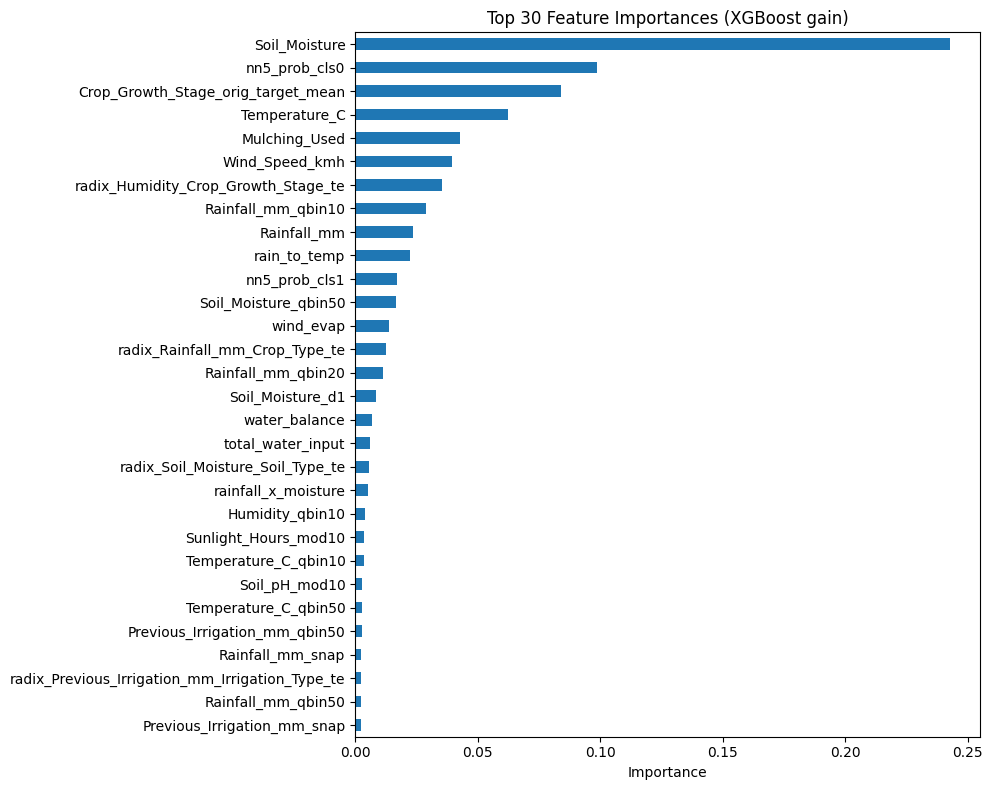


Top 10:
  Soil_Moisture: 0.2428
  nn5_prob_cls0: 0.0986
  Crop_Growth_Stage_orig_target_mean: 0.0841
  Temperature_C: 0.0622
  Mulching_Used: 0.0427
  Wind_Speed_kmh: 0.0393
  radix_Humidity_Crop_Growth_Stage_te: 0.0355
  Rainfall_mm_qbin10: 0.0288
  Rainfall_mm: 0.0235
  rain_to_temp: 0.0222


In [22]:
X_full = X_train_all.copy()
for col in te_cols:
    te_map = pd.Series(y).groupby(X_full[col].values).mean()
    X_full[f'{col}_te'] = X_full[col].map(te_map).fillna(y.mean())
for c in X_full.select_dtypes(include=['object']).columns:
    X_full[c] = X_full[c].astype('category').cat.codes

model_imp = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    tree_method='hist', device='cuda', random_state=SEED, verbosity=0)
model_imp.fit(X_full, y, sample_weight=compute_sample_weights(y))

importance = pd.Series(model_imp.feature_importances_, index=X_full.columns)
top30 = importance.nlargest(30)

fig, ax = plt.subplots(figsize=(10, 8))
top30.sort_values().plot.barh(ax=ax)
ax.set_title('Top 30 Feature Importances (XGBoost gain)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10:")
for feat, imp in top30.head(10).items():
    print(f"  {feat}: {imp:.4f}")

## 14. Resuming After a Crash

Re-run all cells from the top. The checkpoint system will:
1. **Skip feature engineering** if `checkpoints/X_train_all.pkl` exists
2. **Skip any model** whose `checkpoints/oof_<name>.npy` exists
3. **Rebuild stacking** from cached predictions (instant)

To force re-training a specific model:
```python
!rm checkpoints/oof_xgb_base.npy checkpoints/test_xgb_base.npy
```

## References

1. **KGMON Playbook for Tabular Data** — Chris Deotte, 1st Place Playground Series S5E4 (Customer Churn), 2026. [Discussion Post](https://www.kaggle.com/competitions/playground-series-s5e4/discussion/577291)
2. **CTGAN: Modeling Tabular data using Conditional GAN** — Xu et al., NeurIPS 2019. [arXiv:1907.00503](https://arxiv.org/abs/1907.00503)
3. **Entity Embeddings of Categorical Variables** — Guo & Berkhahn, 2016. [arXiv:1604.06737](https://arxiv.org/abs/1604.06737)
4. **FAO Penman-Monteith Evapotranspiration** — FAO Irrigation & Drainage Paper 56. [FAO](https://www.fao.org/3/x0490e/x0490e06.htm)
5. **CatBoost: unbiased boosting with categorical features** — Prokhorenkova et al., NeurIPS 2018. [arXiv:1706.09516](https://arxiv.org/abs/1706.09516)
6. **LightGBM: A Highly Efficient Gradient Boosting Decision Tree** — Ke et al., NeurIPS 2017. [Paper](https://papers.nips.cc/paper/2017/hash/6449f44a102fde848669bdd9eb6b76fa-Abstract.html)
7. **XGBoost: A Scalable Tree Boosting System** — Chen & Guestrin, KDD 2016. [arXiv:1603.02754](https://arxiv.org/abs/1603.02754)
8. **Irrigation Water Requirement Prediction Dataset** — [Kaggle](https://www.kaggle.com/datasets/miadul/irrigation-water-requirement-prediction-dataset/data)

---

*Built as a portfolio piece demonstrating KGMON-style tabular ML: systematic feature engineering, multi-library GBDT diversity, neural network integration, and multi-level stacking.*